# Ranking content-review opportunities from pre-decision search signals

**Author:** Hisham  \n**Capstone:** ML-CAP-01 — Google Search Ranking & Discoverability  \n**Lane:** Refresh / Content Opportunity Scoring  \n**Supporting assignments:** ML-11 — Ship the Paper · ML-12 — Tell the Story  \n**Analysis date:** 2026-09-10

## Abstract

FlyRank's content-review problem is a scarce-attention problem: when a portfolio contains many pages, strategists need a defensible way to decide what to diagnose first. This study asks whether pre-decision Google Search Console aggregates can rank pages for that manual review, using the March 2026 FlyRank ML Internship release, five features aggregated over March 1–20, and a March 21–31 missed-click opportunity proxy on 86,574 eligible pages. A fixed-seed random forest is compared with a transparent rule and a constant dummy on the same six-client grouped holdout, with no client overlap. The model measured median client NDCG@20 of **0.797**, a **15.5% relative gain** over the rule baseline's 0.690, while mean precision@20 decreased from 0.917 to 0.850 and the six-client bootstrap interval remained wide. The output is therefore a human-reviewed prioritization queue, not an automatic editing system or a claim of causal traffic lift.

> This notebook reconstructs every paper table and figure from committed metric receipts. The underlying warehouse notebooks remain the source for feature construction, training, and validation.

## 1. Question

**Research question:** At a March 20 decision point, can five observable search-performance aggregates rank page-level future missed-click opportunity better than a transparent review rule for clients unseen during training?

For FlyRank's content teams, the operational decision is which visible pages to diagnose first within a limited weekly review capacity across a large portfolio. A false positive costs review time and can invite an unnecessary edit; a false negative delays inspection of a potentially valuable page. The output is a within-client rank and suggested review action, always subject to human override.

In [1]:
import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

SEED = 42
ROOT = Path.cwd().resolve()
while not (ROOT / 'work' / 'outputs').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('Run this notebook from inside the repository.')
    ROOT = ROOT.parent
OUTPUTS = ROOT / 'work' / 'outputs'
FIGURES = ROOT / 'work' / 'figures'
PAPER_ASSETS = ROOT / 'docs' / 'assets'
FIGURES.mkdir(parents=True, exist_ok=True)
PAPER_ASSETS.mkdir(parents=True, exist_ok=True)

def load_receipt(name):
    return json.loads((OUTPUTS / name).read_text(encoding='utf-8'))

ml07 = load_receipt('ml07_baseline_metrics.json')
ml08 = load_receipt('ml08_model_metrics.json')
ml09 = load_receipt('ml09_validation_metrics.json')
ml10 = load_receipt('ml10_playbook_metrics.json')
assert ml08['seed'] == ml09['seed'] == ml10['seed'] == SEED
assert ml08['model_rows'] == ml09['model_rows'] == ml10['eligible_pages'] == 86574
print('Loaded four committed receipts; cross-assignment consistency checks passed.')

Loaded four committed receipts; cross-assignment consistency checks passed.


## 2. Data

The source is the approved March 2026 partition of `fact_content_daily_performance` in the FlyRank ML Internship warehouse, whose full release contains roughly 79 million page-day rows. The raw grain is one `report_date × client_hash_id × content_hash_id` page-day; modeling aggregates to one pseudonymized content page at the March 20 decision cutoff.

Features cover **March 1–20, 2026**; the observed proxy covers **March 21–31**. June 2026 remained sealed and was not read. Rows required GSC availability, at least 100 feature-window impressions, at least one outcome-window impression, and a client with at least 100 eligible pages, leaving 86,574 pages across 22 pseudonymized clients. This survivorship filter excludes disappearing and very low-volume pages.

Only five pre-decision features enter the model: impressions, clicks, impression-weighted average position, active days, and CTR. Client/content hashes are used only for grouping and joins. Future-window fields, `trend_direction`, `trend_pct`, GA4 fields, URLs, titles, and raw queries are excluded from features and public artifacts.

In [2]:
study_design = pd.DataFrame([
    ('Source', 'FlyRank ML Internship warehouse — March 2026 release'),
    ('Raw grain', 'page-day; pseudonymous client and content keys'),
    ('Feature window', '2026-03-01 through 2026-03-20'),
    ('Outcome window', '2026-03-21 through 2026-03-31'),
    ('Eligible model rows', f"{ml08['model_rows']:,} pages"),
    ('Grouped holdout', f"{ml08['train_clients']} train clients / {ml08['test_clients']} unseen clients"),
    ('Sealed period', 'June 2026 not read'),
], columns=['Design item', 'Value'])
display(study_design)

,Design item,Value
0,Source,FlyRank ML Internship warehouse — March 2026 r...
1,Raw grain,page-day; pseudonymous client and content keys
2,Feature window,2026-03-01 through 2026-03-20
3,Outcome window,2026-03-21 through 2026-03-31
4,Eligible model rows,"86,574 pages"
5,Grouped holdout,16 train clients / 6 unseen clients
6,Sealed period,June 2026 not read


## 3. Methodology

The target is a non-negative **future missed-click opportunity proxy**: future impressions multiplied by the positive gap between a page's future CTR and the training clients' CTR for the same future-position band. It is an observed ranking proxy, not incremental clicks and not revenue.

The transparent baseline scores pages with at least 500 prior impressions, prior average position 4–20, and CTR below a position-band rate estimated only on training clients. The learned method is a random forest regressor (200 trees, maximum depth 10, minimum leaf size 20, 80% feature sampling) fit to `log1p(target)` with seed 42. A constant-mean dummy establishes a floor.

Validation uses a fixed 75/25 `GroupShuffleSplit` by client: 16 training clients and six unseen test clients, with zero overlap. Every method is scored on the same 10,253 held-out pages. The primary metric is median client NDCG@20; mean client precision@20 and MAE expose different tradeoffs. A deliberate future-field leak probe jumped NDCG@20 to 1.000 and was rejected; identifiers, outcomes, and product-derived trend fields remain outside the production feature list.

,Method,Median client NDCG@20,Mean client precision@20,MAE
0,Dummy mean,0.044,0.683,1.237
1,Week-4 rule baseline,0.690,0.917,0.486
2,Random Forest,0.797,0.850,0.430


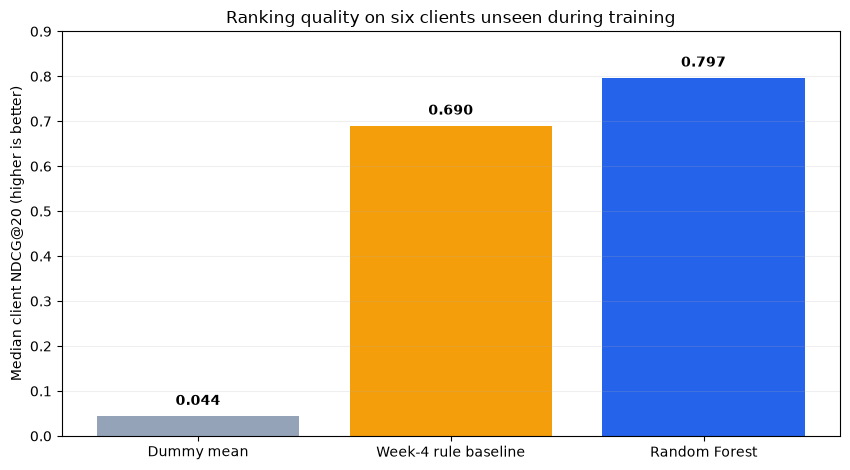

In [3]:
comparison = pd.DataFrame(ml08['comparison']).rename(columns={
    'method': 'Method', 'median_client_ndcg_at_20': 'Median client NDCG@20',
    'mean_client_precision_at_20': 'Mean client precision@20', 'mae_future_missed_clicks': 'MAE',
})
display(comparison[['Method', 'Median client NDCG@20', 'Mean client precision@20', 'MAE']].style.format({'Median client NDCG@20': '{:.3f}', 'Mean client precision@20': '{:.3f}', 'MAE': '{:.3f}'}))
colors = ['#94a3b8', '#f59e0b', '#2563eb']
fig, ax = plt.subplots(figsize=(8.6, 4.8))
bars = ax.bar(comparison['Method'], comparison['Median client NDCG@20'], color=colors)
ax.set_ylim(0, 0.9); ax.set_ylabel('Median client NDCG@20 (higher is better)')
ax.set_title('Ranking quality on six clients unseen during training'); ax.grid(axis='y', alpha=.2)
for bar, value in zip(bars, comparison['Median client NDCG@20']):
    ax.text(bar.get_x() + bar.get_width()/2, value + .025, f'{value:.3f}', ha='center', fontweight='bold')
fig.tight_layout()
result_figure = FIGURES / 'ml11_model_comparison.png'
fig.savefig(result_figure, dpi=180, bbox_inches='tight')
shutil.copyfile(result_figure, PAPER_ASSETS / result_figure.name)
plt.show()

## 4. Results (vs baseline)

On the grouped holdout, the random forest measured **0.797 median client NDCG@20**, compared with **0.690** for the rule baseline and 0.044 for the dummy. That is a **15.5% relative NDCG gain** over the rule. MAE also decreased from 0.486 to 0.430 (11.5% lower).

The model did not dominate every metric: mean precision@20 was **0.850**, below the rule baseline's **0.917**, against a held-out positive-target base rate of **0.626**. The model improved the ordering of opportunity magnitude while the stricter rule placed more binary-positive pages in the first 20. The bootstrap 95% interval for the model's median client NDCG@20 was **0.405–0.876**, which is wide because only six clients were held out. These measurements support cautious decision use, not a universal superiority claim.

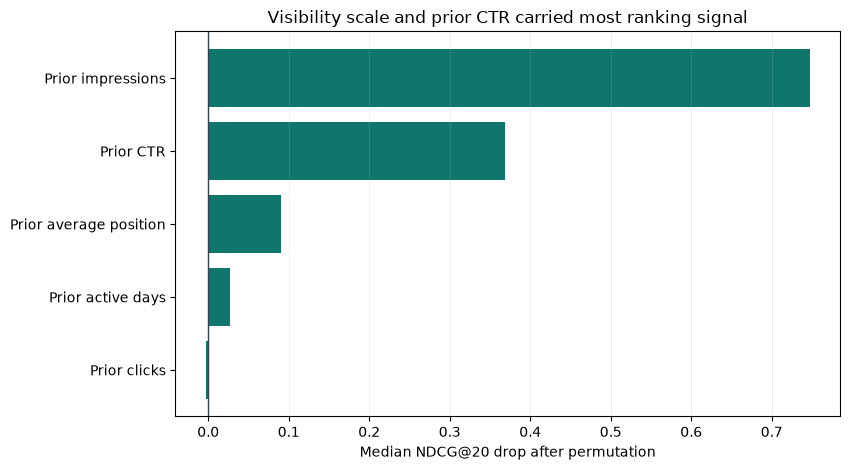

,feature,median_ndcg_drop,repeat_sd
0,prior_impressions,0.747,0.007
1,prior_ctr_pct,0.368,0.077
2,prior_avg_position,0.091,0.063
3,prior_active_days,0.028,0.004
4,prior_clicks,-0.003,0.002


In [4]:
importance = pd.DataFrame(ml08['permutation_importance']).sort_values('median_ndcg_drop')
labels = {'prior_impressions':'Prior impressions','prior_ctr_pct':'Prior CTR','prior_avg_position':'Prior average position','prior_active_days':'Prior active days','prior_clicks':'Prior clicks'}
fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.barh(importance['feature'].map(labels), importance['median_ndcg_drop'], color='#0f766e')
ax.axvline(0, color='#334155', linewidth=1); ax.set_xlabel('Median NDCG@20 drop after permutation')
ax.set_title('Visibility scale and prior CTR carried most ranking signal'); ax.grid(axis='x', alpha=.2)
fig.tight_layout()
importance_figure = FIGURES / 'ml11_permutation_importance.png'
fig.savefig(importance_figure, dpi=180, bbox_inches='tight')
shutil.copyfile(importance_figure, PAPER_ASSETS / importance_figure.name)
plt.show()
display(importance[['feature','median_ndcg_drop','repeat_sd']].sort_values('median_ndcg_drop',ascending=False).style.format({'median_ndcg_drop':'{:.3f}','repeat_sd':'{:.3f}'}))

## 5. Limitations & honest framing

This is an observational, one-month study with a short forward outcome window and only six held-out clients. Eligibility requires activity in both windows, so the result does not cover new, disappearing, or very low-volume pages. The target depends on future position-band peer CTR and represents measured opportunity under an explicit proxy—not traffic caused by an edit.

The feature set omits query intent, SERP features, branded mix, CMS freshness, content quality, conversions, seasonality, interventions, and business value. Permutation importance describes this fitted model on this split; it does not establish causal drivers. The random forest was compared once on a fixed grouped split rather than across many forward periods, and the bootstrap interval is correspondingly wide. Forward validation on later labeled windows and a controlled intervention study are required before stronger claims or operational automation.

In [5]:
baseline = comparison.loc[comparison['Method'] == 'Week-4 rule baseline'].iloc[0]
model = comparison.loc[comparison['Method'] == 'Random Forest'].iloc[0]
tradeoffs = pd.DataFrame([
 ('Median client NDCG@20',baseline['Median client NDCG@20'],model['Median client NDCG@20'],'Model orders opportunity magnitude better'),
 ('Mean client precision@20',baseline['Mean client precision@20'],model['Mean client precision@20'],'Rule includes more binary-positive pages'),
 ('MAE',baseline['MAE'],model['MAE'],'Model has lower score error')],
 columns=['Metric','Rule baseline','Random forest','Interpretation'])
display(tradeoffs.style.format({'Rule baseline':'{:.3f}','Random forest':'{:.3f}'}))
print('Uncertainty: grouped median NDCG@20 bootstrap 95% interval', ml09['grouped_median_client_ndcg_at_20_bootstrap_95pct'])

,Metric,Rule baseline,Random forest,Interpretation
0,Median client NDCG@20,0.690,0.797,Model orders opportunity magnitude better
1,Mean client precision@20,0.917,0.850,Rule includes more binary-positive pages
2,MAE,0.486,0.430,Model has lower score error


Uncertainty: grouped median NDCG@20 bootstrap 95% interval [0.405068, 0.876476]


## 6. Ranked recommendations

The playbook exports 60 candidates—ten per unseen client—to prevent the largest portfolio from dominating. Every row requires human review. The current mix contains 41 snippet/intent reviews, six monitor decisions, five requests for more evidence, four protect-and-monitor cases, and four content-refresh reviews.

**Review order:** (1) inspect high-ranked page-one under-capture candidates for query/intent and snippet fit; (2) investigate striking-distance candidates for stale facts, missing coverage, or internal-link gaps; (3) protect strong top-three assets and monitor rather than edit; (4) defer thin-history pages until more evidence arrives. Each reason code explains which observable conditions put a page in the queue. Value tiers and effort bands are relative planning aids, not revenue estimates.

**Never automate from this queue:** publishing, rewriting, deleting, redirecting, de-indexing, causal uplift claims, personnel judgments, or actions on legal/medical/financial/high-brand-risk content. A reviewer must inspect actual intent, CMS history, outages, migrations, seasonality, brand and legal constraints, and define a 30/60-day measurement plan before any change.

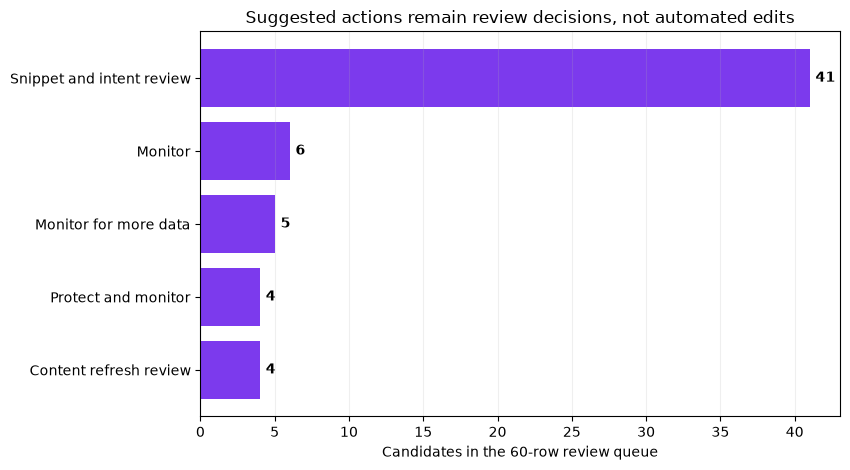

,Rank,Review action,Reason,Human decision
0,1,Snippet and intent review,Page-one visibility + CTR below training peers,Inspect queries and SERP context; human choose...
1,2,Content refresh review,Striking-distance position + observed under-ca...,Verify CMS age and factual gaps; never refresh...
2,3,Protect and monitor,Top-three visibility,Avoid unnecessary edits; watch for material mo...
3,4,Monitor for more data,Thin observation history,Defer action until evidence is sufficient


In [6]:
action_labels={'SNIPPET_INTENT_REVIEW':'Snippet and intent review','CONTENT_REFRESH_REVIEW':'Content refresh review','PROTECT_AND_MONITOR':'Protect and monitor','MONITOR_MORE_DATA':'Monitor for more data','MONITOR':'Monitor'}
action_mix = pd.Series(ml10['action_mix']).sort_values()
fig, ax = plt.subplots(figsize=(8.6,4.8))
ax.barh([action_labels[x] for x in action_mix.index], action_mix.values, color='#7c3aed')
ax.set_xlabel('Candidates in the 60-row review queue'); ax.set_title('Suggested actions remain review decisions, not automated edits'); ax.grid(axis='x',alpha=.2)
for i,value in enumerate(action_mix.values): ax.text(value+.4,i,str(value),va='center',fontweight='bold')
fig.tight_layout()
action_figure = FIGURES / 'ml11_action_mix.png'
fig.savefig(action_figure,dpi=180,bbox_inches='tight'); shutil.copyfile(action_figure,PAPER_ASSETS/action_figure.name); plt.show()
recommendations=pd.DataFrame([
 (1,'Snippet and intent review','Page-one visibility + CTR below training peers','Inspect queries and SERP context; human chooses change or no change'),
 (2,'Content refresh review','Striking-distance position + observed under-capture','Verify CMS age and factual gaps; never refresh by age alone'),
 (3,'Protect and monitor','Top-three visibility','Avoid unnecessary edits; watch for material movement'),
 (4,'Monitor for more data','Thin observation history','Defer action until evidence is sufficient')],
 columns=['Rank','Review action','Reason','Human decision'])
display(recommendations); assert ml10['human_review_required_pct'] == 100.0

## 7. Reproducibility and paper artifacts

From a fresh clone, install `requirements.txt`, authenticate only through `HF_TOKEN` or point `FLYRANK_MARCH_PARQUET` to an approved local March partition, then run the notebooks in assignment order. `w05_model.ipynb` builds the frozen model comparison; `w06_validation_audit.ipynb` reproduces the leakage and uncertainty audit; `w07_action_playbook.ipynb` regenerates the ignored row-level queue; this notebook rebuilds the public aggregate tables and figures from committed JSON receipts.

All randomized steps use seed 42. The model receipt records scikit-learn 1.9.0, pandas 3.0.5, and DuckDB 1.5.5. The public paper embeds only aggregate charts. No client names, content hashes, URLs, titles, raw queries, credentials, or row-level outcomes are copied into `docs/`.

In [7]:
paper_metrics={
 'assignment':'ML-11','seed':SEED,'eligible_pages':ml08['model_rows'],'held_out_clients':ml08['test_clients'],
 'model_median_client_ndcg_at_20':round(float(model['Median client NDCG@20']),6),
 'baseline_median_client_ndcg_at_20':round(float(baseline['Median client NDCG@20']),6),
 'relative_ndcg_gain_vs_baseline':ml08['relative_median_ndcg_gain_vs_baseline'],
 'model_mean_precision_at_20':round(float(model['Mean client precision@20']),6),
 'baseline_mean_precision_at_20':round(float(baseline['Mean client precision@20']),6),
 'model_mae':round(float(model['MAE']),6),'baseline_mae':round(float(baseline['MAE']),6),
 'bootstrap_95pct':ml09['grouped_median_client_ndcg_at_20_bootstrap_95pct'],
 'queue_candidates':ml10['queue_candidates'],'human_review_required_pct':ml10['human_review_required_pct'],
 'claim_scope':'observational_directional_decision_support'}
receipt_path=OUTPUTS/'ml11_paper_metrics.json'
receipt_path.write_text(json.dumps(paper_metrics,indent=2)+'\n',encoding='utf-8')
required_assets=[PAPER_ASSETS/'ml11_model_comparison.png',PAPER_ASSETS/'ml11_permutation_importance.png',PAPER_ASSETS/'ml11_action_mix.png']
assert all(path.exists() and path.stat().st_size>10_000 for path in required_assets)
assert (ROOT/'docs'/'index.html').exists()
print('Wrote work/outputs/ml11_paper_metrics.json and verified three paper figures.')

Wrote work/outputs/ml11_paper_metrics.json and verified three paper figures.


## Self-check

- [x] Question, data, methodology, results, limitations, ranked recommendations, and reproducibility are complete.
- [x] The model, rule baseline, and dummy use the same grouped holdout; base rate and uncertainty remain visible.
- [x] The deliberate leak is documented as invalid and excluded from every claim.
- [x] All paper numbers trace to committed receipts and all paper figures are regenerated here.
- [x] Claims remain measured, observational, directional, and decision-support.
- [x] Public artifacts contain no client names, identifiers, URLs, private queries, credentials, or row-level exports.
- [x] The deployed paper contains all nine required sections, including a five-sentence abstract and linked FlyRank data credit.
- [x] The notebook runs top to bottom with no errors.

## ML-12 · Five-minute demo outline

**0:00–0:35 — FlyRank content problem and question.** A content team cannot inspect every page at once. Ask: can five signals already observable at a March 20 decision point rank future missed-click opportunity better than a transparent review rule for clients the model has never seen?

**0:35–1:15 — Data and safety boundary.** Use 86,574 eligible pages from the approved March 2026 release. Aggregate March 1–20 for features, reserve March 21–31 for the observed outcome, keep six entire clients out of training, and exclude identifiers, future fields, URLs, titles, and raw queries.

**1:15–2:15 — Method.** Compare a fixed-seed random forest against the same transparent rule and constant dummy on the identical grouped holdout. Lead with median client NDCG@20 because the product decision is a within-client top-20 queue; keep precision@20, MAE, the held-out positive rate, leakage probes, and client bootstrap uncertainty visible.

**2:15–3:20 — One chart.** Show Figure 1, *Same split, different trade-offs*. Point first to NDCG@20: 0.797 for the model versus 0.690 for the rule. Then point to the trade-off in the same chart: mean precision@20 is 0.850 versus 0.917, so the model improves ordering but does not win every metric.

**3:20–4:10 — One honest result.** On six unseen clients, the measured median NDCG@20 gain is 15.5% relative to the rule, but the six-client bootstrap interval is wide (0.405–0.876). This is observational decision-support evidence—not proof that an edit will cause traffic lift.

**4:10–4:50 — One recommendation.** Start with page-one pages whose click capture trails training-client peers, then have a strategist inspect query intent and the live search result before choosing change or no change. The system prioritizes investigation; it never publishes, rewrites, redirects, or deletes automatically.

**4:50–5:00 — Close.** The practical deliverable is a reproducible, public-safe 60-row review queue with a human decision on every candidate. Invite the audience to inspect the live paper and repository.

## ML-12 · Shareable cuts

### Short social post

How should a content team decide which pages deserve scarce review time? I built a public-safe ranking study on 86,574 eligible pages from the FlyRank ML Internship dataset, using five pre-decision search aggregates and holding out six entire clients. The random forest measured median client NDCG@20 of 0.797 versus 0.690 for a transparent rule (+15.5% relative), although precision@20 fell from 0.917 to 0.850 and uncertainty across six clients remained wide. Figure 1 shows that trade-off; the output is a human-reviewed investigation queue, not an automatic editor or a causal uplift claim. Read the paper: https://hisham-walid.github.io/flyrank-ml-internship/

### Employer-facing summary — three sentences

I built a reproducible content-review prioritization pipeline and public research page that compare a fixed-seed random forest with transparent rule and dummy baselines. The study uses 86,574 eligible pages from the March 2026 FlyRank ML Internship release, a strict pre/post time boundary, and a six-client grouped holdout with leakage and uncertainty checks. It measured median client NDCG@20 of 0.797 versus 0.690 for the rule while surfacing a precision trade-off, supporting a human-reviewed queue rather than automated edits or causal traffic-lift claims.